# MWPM Threshold: Full Logical vs Physical Error Rate

Verify that MWPM suppresses the logical error rate below the physical error rate for small enough p.

## Why full logical error rate?

The ML (PEPS) decoder predicts all 4 cosets `(lx, lz)` simultaneously using both sX and sZ syndromes.
A failure occurs if **either** the X-type or Z-type logical prediction is wrong.

For a fair comparison, MWPM must also be evaluated on **both** logical observables:
- `memory_x` experiment → predicts Z-type logical errors (`lz`), tracks via X-check syndrome
- `memory_z` experiment → predicts X-type logical errors (`lx`), tracks via Z-check syndrome

Under code-capacity depolarizing noise, the X and Z error channels are **exactly independent**
(Y errors contribute to both channels but independently). So we can run both experiments
separately and combine:

$$p_L^\text{full} = 1 - (1 - p_L^X)(1 - p_L^Z)$$

## Pipeline per data point
1. Sample syndromes from Stim (code-capacity depolarizing) — once for each memory basis
2. Decode with MWPM (PyMatching) in each basis
3. Combine X and Z logical error rates → full logical error rate

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from src.mwpm_decoder import run_surface_code_mwpm_full_logical

In [2]:
# ── Sweep parameters ──────────────────────────────────────────────────────────
distances = [3, 5, 7]                      # surface code distances
p_values  = np.geomspace(0.01, 0.20, 14)  # physical error rates
shots     = 5_000                          # samples per (distance, p, basis)

# ── Run sweep ─────────────────────────────────────────────────────────────────
# results[d] = {'p_L_X': [...], 'p_L_Z': [...], 'p_L_full': [...]}
results = {}

for d in distances:
    print(f'distance = {d}')
    p_L_X, p_L_Z, p_L_full = [], [], []
    for p in p_values:
        res = run_surface_code_mwpm_full_logical(
            distance=d,
            p=float(p),
            shots=shots,
        )
        p_L_X.append(res.p_L_X)
        p_L_Z.append(res.p_L_Z)
        p_L_full.append(res.logical_error_rate)
        print(f'  p={p:.4f}  p_L_X={res.p_L_X:.4f}  p_L_Z={res.p_L_Z:.4f}  p_L_full={res.logical_error_rate:.4f}')
    results[d] = {
        'p_L_X':   np.array(p_L_X),
        'p_L_Z':   np.array(p_L_Z),
        'p_L_full': np.array(p_L_full),
    }

print('Done.')

distance = 3
  p=0.0100  p_L_X=0.0038  p_L_Z=0.0034  p_L_full=0.0072
  p=0.0126  p_L_X=0.0042  p_L_Z=0.0050  p_L_full=0.0092
  p=0.0159  p_L_X=0.0074  p_L_Z=0.0076  p_L_full=0.0149
  p=0.0200  p_L_X=0.0118  p_L_Z=0.0140  p_L_full=0.0256
  p=0.0251  p_L_X=0.0178  p_L_Z=0.0206  p_L_full=0.0380
  p=0.0317  p_L_X=0.0276  p_L_Z=0.0286  p_L_full=0.0554
  p=0.0399  p_L_X=0.0446  p_L_Z=0.0534  p_L_full=0.0956
  p=0.0502  p_L_X=0.0676  p_L_Z=0.0590  p_L_full=0.1226
  p=0.0632  p_L_X=0.1008  p_L_Z=0.0988  p_L_full=0.1896
  p=0.0796  p_L_X=0.1510  p_L_Z=0.1478  p_L_full=0.2765
  p=0.1002  p_L_X=0.2092  p_L_Z=0.2018  p_L_full=0.3688
  p=0.1261  p_L_X=0.2786  p_L_Z=0.2690  p_L_full=0.4727
  p=0.1588  p_L_X=0.3448  p_L_Z=0.3524  p_L_full=0.5757
  p=0.2000  p_L_X=0.4108  p_L_Z=0.4226  p_L_full=0.6598
distance = 5
  p=0.0100  p_L_X=0.0000  p_L_Z=0.0000  p_L_full=0.0000
  p=0.0126  p_L_X=0.0002  p_L_Z=0.0004  p_L_full=0.0006
  p=0.0159  p_L_X=0.0006  p_L_Z=0.0020  p_L_full=0.0026
  p=0.0200  p_L_X=0.00

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

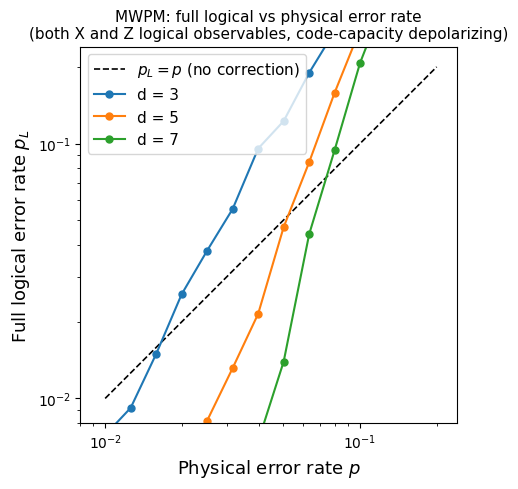

Saved mwpm_threshold.png


In [3]:
# ── Plot: full logical error rate ─────────────────────────────────────────────
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(7, 5))

# Reference line: no correction, p_L = p
ax.plot(p_values, p_values, 'k--', linewidth=1.2, label='$p_L = p$ (no correction)')

for d, color in zip(distances, colors):
    ax.plot(p_values, results[d]['p_L_full'], 'o-',
            color=color, label=f'd = {d}', markersize=5)

ax.set_xlabel('Physical error rate $p$', fontsize=13)
ax.set_ylabel('Full logical error rate $p_L$', fontsize=13)
ax.set_title(
    'MWPM: full logical vs physical error rate\n'
    '(both X and Z logical observables, code-capacity depolarizing)',
    fontsize=11,
)
ax.legend(fontsize=11)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_aspect('equal')
ax.set_xlim(p_values[0] * 0.8, p_values[-1] * 1.2)
ax.set_ylim(p_values[0] * 0.8, p_values[-1] * 1.2)

plt.tight_layout()
plt.savefig('mwpm_threshold.png', dpi=150)
plt.show()
print('Saved mwpm_threshold.png')

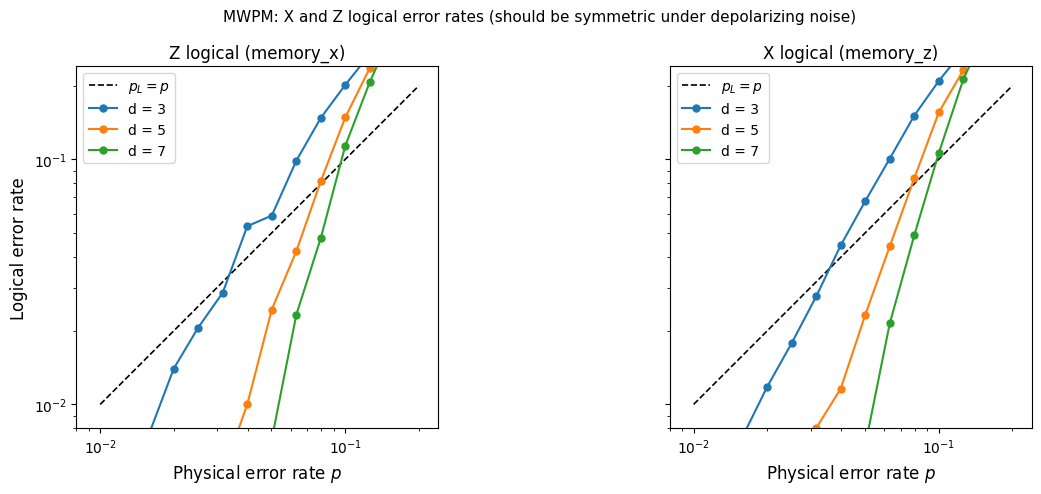

In [4]:
# ── Optional: show X and Z rates separately to confirm symmetry ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, key, label in zip(axes, ['p_L_Z', 'p_L_X'], ['Z logical (memory_x)', 'X logical (memory_z)']):
    ax.plot(p_values, p_values, 'k--', linewidth=1.2, label='$p_L = p$')
    for d, color in zip(distances, colors):
        ax.plot(p_values, results[d][key], 'o-', color=color, label=f'd = {d}', markersize=5)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Physical error rate $p$', fontsize=12)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_aspect('equal')
    ax.set_xlim(p_values[0] * 0.8, p_values[-1] * 1.2)
    ax.set_ylim(p_values[0] * 0.8, p_values[-1] * 1.2)
    ax.legend(fontsize=10)

axes[0].set_ylabel('Logical error rate', fontsize=12)
fig.suptitle('MWPM: X and Z logical error rates (should be symmetric under depolarizing noise)', fontsize=11)
plt.tight_layout()
plt.show()

In [5]:
# ── Summary table ─────────────────────────────────────────────────────────────
col_w = 12
header = f"{'p':>8}" + "".join(
    f"{'d='+str(d)+' pLX':>{col_w}}{'d='+str(d)+' pLZ':>{col_w}}{'d='+str(d)+' full':>{col_w}}"
    for d in distances
)
print(header)
print('-' * len(header))
for i, p in enumerate(p_values):
    row = f"{p:8.4f}" + "".join(
        f"{results[d]['p_L_X'][i]:{col_w}.4f}"
        f"{results[d]['p_L_Z'][i]:{col_w}.4f}"
        f"{results[d]['p_L_full'][i]:{col_w}.4f}"
        for d in distances
    )
    print(row)

       p     d=3 pLX     d=3 pLZ    d=3 full     d=5 pLX     d=5 pLZ    d=5 full     d=7 pLX     d=7 pLZ    d=7 full
--------------------------------------------------------------------------------------------------------------------
  0.0100      0.0038      0.0034      0.0072      0.0000      0.0000      0.0000      0.0000      0.0000      0.0000
  0.0126      0.0042      0.0050      0.0092      0.0002      0.0004      0.0006      0.0000      0.0000      0.0000
  0.0159      0.0074      0.0076      0.0149      0.0006      0.0020      0.0026      0.0000      0.0000      0.0000
  0.0200      0.0118      0.0140      0.0256      0.0016      0.0010      0.0026      0.0000      0.0000      0.0000
  0.0251      0.0178      0.0206      0.0380      0.0048      0.0034      0.0082      0.0006      0.0000      0.0006
  0.0317      0.0276      0.0286      0.0554      0.0080      0.0052      0.0132      0.0016      0.0014      0.0030
  0.0399      0.0446      0.0534      0.0956      0.0116      0.